# Customer Segmentation using K-Means Clustering

This notebook performs customer segmentation by:
1. Loading and exploring customer data
2. Scaling features (Age, Income)
3. Using the elbow method to find optimal clusters
4. Applying K-Means clustering
5. Visualizing and profiling segments
6. Generating actionable marketing reports

## Section 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

## Section 2: Load and Explore Customer Dataset

In [2]:
# Load customer data
df = pd.read_csv('customers.csv')

# Display first rows
print("First few rows of the dataset:")
print(df.head())

# Dataset info
print("\n=== Dataset Info ===")
print(f"Shape: {df.shape}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isnull().sum()}")

# Basic statistics
print("\n=== Statistical Summary ===")
print(df.describe())

First few rows of the dataset:
      Name  Age  Income  SpendingScore
0    Alice   25   30000             70
1      Bob   31   45000             65
2  Charlie   28   35000             55
3    Diana   35   50000             75
4      Eve   29   40000             60

=== Dataset Info ===
Shape: (26, 4)

Data Types:
Name             object
Age               int64
Income            int64
SpendingScore     int64
dtype: object

Missing Values:
Name             0
Age              0
Income           0
SpendingScore    0
dtype: int64

=== Statistical Summary ===
             Age        Income  SpendingScore
count  26.000000     26.000000      26.000000
mean   33.346154  46961.538462      67.192308
std     6.590553  12137.481680      11.317311
min    24.000000  28000.000000      45.000000
25%    28.000000  36500.000000      59.250000
50%    32.500000  47000.000000      69.000000
75%    38.750000  55750.000000      75.750000
max    45.000000  70000.000000      85.000000


## Section 3: Data Cleaning and Feature Scaling

In [3]:
# Extract features for clustering: Age and Income
X = df[['Age', 'Income']].copy()

# Check for missing values
print("Missing values before cleaning:")
print(X.isnull().sum())

# Drop rows with missing values (if any)
X = X.dropna()

print(f"\nFeatures shape after cleaning: {X.shape}")

# Scale features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled features (first 5 rows):")
print(X_scaled[:5])

# Convert to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=['Age_scaled', 'Income_scaled'])

Missing values before cleaning:
Age       0
Income    0
dtype: int64

Features shape after cleaning: (26, 2)

Scaled features (first 5 rows):
[[-1.29146077 -1.4251262 ]
 [-0.36303736 -0.16481051]
 [-0.82724907 -1.00502097]
 [ 0.25591158  0.25529472]
 [-0.67251183 -0.58491574]]


## Section 4: Determine Optimal Clusters with Elbow Method

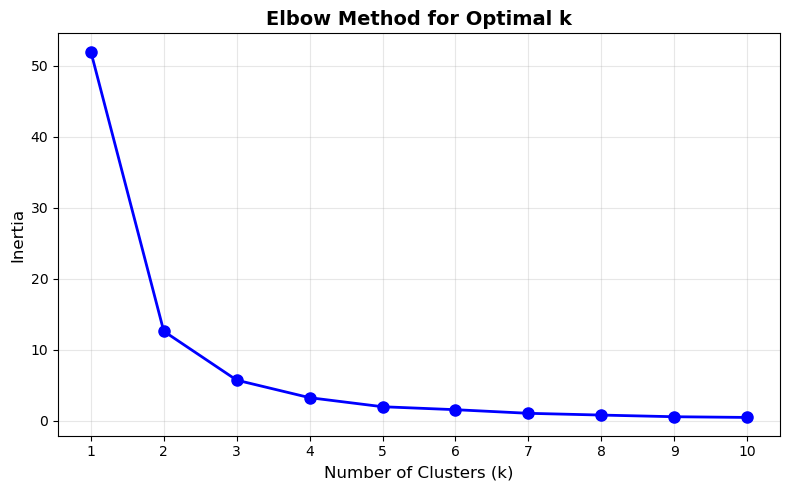


Inertia values for different k:
k=1: Inertia=52.00
k=2: Inertia=12.62
k=3: Inertia=5.73
k=4: Inertia=3.26
k=5: Inertia=1.99
k=6: Inertia=1.57
k=7: Inertia=1.06
k=8: Inertia=0.81
k=9: Inertia=0.58
k=10: Inertia=0.48


In [4]:
# Elbow Method: Calculate inertia for different k values
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_scaled)
    inertias.append(kmeans_temp.inertia_)

# Plot elbow curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.tight_layout()
plt.show()

print("\nInertia values for different k:")
for k, inertia in zip(K_range, inertias):
    print(f"k={k}: Inertia={inertia:.2f}")

## Section 5: Apply K-Means Clustering

Based on the elbow method, we choose **k=3** clusters (you can adjust based on the elbow curve).

In [5]:
# Apply K-Means with optimal k
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters

print(f"K-Means clustering applied with k={optimal_k}")
print(f"\nCluster distribution:")
print(df_with_clusters['Cluster'].value_counts().sort_index())
print(f"\nFirst few rows with cluster assignments:")
print(df_with_clusters.head(10))

K-Means clustering applied with k=3

Cluster distribution:
Cluster
0    11
1     7
2     8
Name: count, dtype: int64

First few rows with cluster assignments:
      Name  Age  Income  SpendingScore  Cluster
0    Alice   25   30000             70        0
1      Bob   31   45000             65        2
2  Charlie   28   35000             55        0
3    Diana   35   50000             75        2
4      Eve   29   40000             60        0
5    Frank   42   60000             80        1
6    Grace   26   32000             50        0
7    Henry   38   55000             72        2
8      Ivy   33   48000             68        2
9     Jack   45   70000             85        1


## Section 6: Visualize Clusters

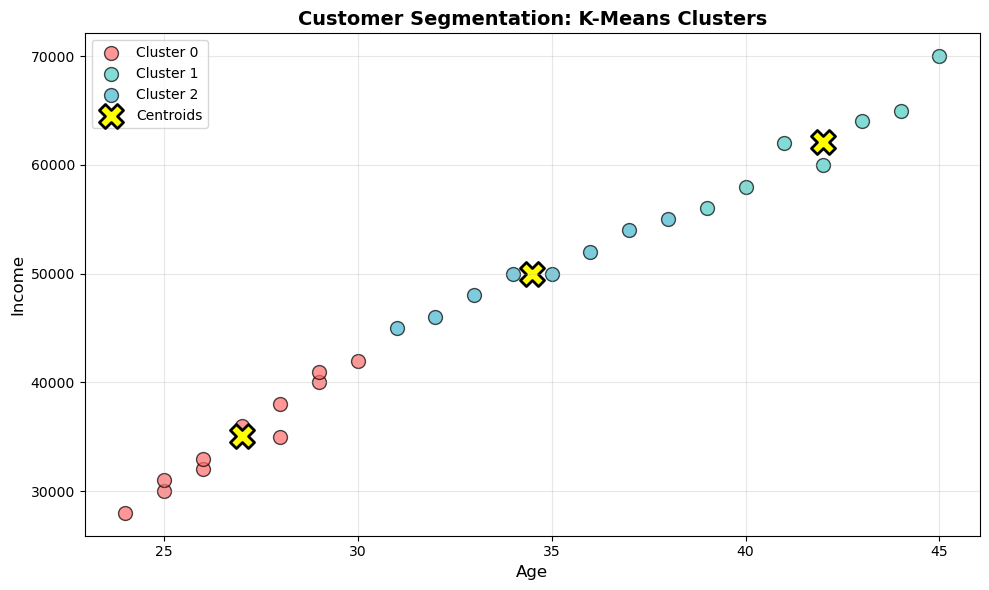

In [6]:
# Create scatter plot of clusters
plt.figure(figsize=(10, 6))

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
for i in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == i]
    plt.scatter(cluster_data['Age'], cluster_data['Income'], 
                c=colors[i], label=f'Cluster {i}', s=100, alpha=0.7, edgecolors='black')

# Plot cluster centers (transform back to original scale)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='yellow', marker='X', s=300, 
            edgecolors='black', linewidth=2, label='Centroids')

plt.xlabel('Age', fontsize=12)
plt.ylabel('Income', fontsize=12)
plt.title('Customer Segmentation: K-Means Clusters', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7: Profile and Analyze Segments

In [7]:
# Profile each cluster
print("=" * 60)
print("CLUSTER PROFILES")
print("=" * 60)

cluster_profiles = []

for i in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == i]
    
    profile = {
        'Cluster': i,
        'Size': len(cluster_data),
        'Avg_Age': cluster_data['Age'].mean(),
        'Avg_Income': cluster_data['Income'].mean(),
        'Avg_SpendingScore': cluster_data['SpendingScore'].mean(),
        'Min_Age': cluster_data['Age'].min(),
        'Max_Age': cluster_data['Age'].max(),
        'Min_Income': cluster_data['Income'].min(),
        'Max_Income': cluster_data['Income'].max()
    }
    
    cluster_profiles.append(profile)
    
    print(f"\nCluster {i}:")
    print(f"  Size: {profile['Size']} customers")
    print(f"  Age: {profile['Avg_Age']:.1f} (range: {profile['Min_Age']}-{profile['Max_Age']})")
    print(f"  Income: ${profile['Avg_Income']:.0f} (range: ${profile['Min_Income']}-${profile['Max_Income']})")
    print(f"  Spending Score: {profile['Avg_SpendingScore']:.1f}")

# Convert to DataFrame
profile_df = pd.DataFrame(cluster_profiles)
print("\n" + "=" * 60)
print("CLUSTER SUMMARY TABLE")
print("=" * 60)
print(profile_df.to_string(index=False))

CLUSTER PROFILES

Cluster 0:
  Size: 11 customers
  Age: 27.0 (range: 24-30)
  Income: $35091 (range: $28000-$42000)
  Spending Score: 56.5

Cluster 1:
  Size: 7 customers
  Age: 42.0 (range: 39-45)
  Income: $62143 (range: $56000-$70000)
  Spending Score: 80.1

Cluster 2:
  Size: 8 customers
  Age: 34.5 (range: 31-38)
  Income: $50000 (range: $45000-$55000)
  Spending Score: 70.5

CLUSTER SUMMARY TABLE
 Cluster  Size  Avg_Age   Avg_Income  Avg_SpendingScore  Min_Age  Max_Age  Min_Income  Max_Income
       0    11     27.0 35090.909091          56.545455       24       30       28000       42000
       1     7     42.0 62142.857143          80.142857       39       45       56000       70000
       2     8     34.5 50000.000000          70.500000       31       38       45000       55000


## Section 8: Save Cluster Labels and Generate Report

In [8]:
# Save customer data with cluster assignments
output_file = 'customers_with_clusters.csv'
df_with_clusters.to_csv(output_file, index=False)
print(f"Cluster assignments saved to: {output_file}")

# Run the report generation script
import subprocess

try:
    result = subprocess.run(['python', 'generate_report.py'], 
                          capture_output=True, text=True, timeout=10)
    print("\n" + "=" * 60)
    print("REPORT GENERATION OUTPUT:")
    print("=" * 60)
    print(result.stdout)
    
    if result.stderr:
        print("Warnings/Errors:")
        print(result.stderr)
except FileNotFoundError:
    print("Note: generate_report.py not found. Report script needs to be created.")
except Exception as e:
    print(f"Note: Could not run report script: {e}")

print("\n✓ Customer segmentation analysis complete!")

Cluster assignments saved to: customers_with_clusters.csv

REPORT GENERATION OUTPUT:

CUSTOMER SEGMENTATION REPORT
Generated: 2026-05-14 12:37:57


──────────────────────────────────────────────────────────────────────
SEGMENT 0: Budget Conscious
──────────────────────────────────────────────────────────────────────

Customer Base:
  • Total Customers: 11
  • Percentage: 42.3%

Demographics:
  • Average Age: 27.0 years
  • Age Range: 24-30 years
  • Average Income: $35091
  • Income Range: $28000-$42000

Behavior:
  • Average Spending Score: 56.5/100
  • Spending Range: 45-70

Recommended Marketing Actions:
  1. Offer discounts and promotional deals
  2. Bundle products for value pricing
  3. Loyalty program with cashback rewards
  4. Email campaigns for clearance sales

Sample Customers:
  • Alice: Age 25, Income $30000, Spending Score 70
  • Charlie: Age 28, Income $35000, Spending Score 55
  • Eve: Age 29, Income $40000, Spending Score 60

───────────────────────────────────────────